**Author:** Christi Maria Biju

**Project:** Car Evaluation using Decision Tree Classification

**Algorithm:** Decision Tree Classifier

**Dataset:** Car Evaluation Dataset

# Car Evaluation using Decision Tree Classification

## Problem Statement

The objective of this project is to develop a machine learning model that predicts the acceptability of a car based on its characteristics.

The Decision Tree Classification algorithm is used to classify cars into different categories according to features such as buying price, maintenance cost, number of doors, seating capacity, luggage boot size, and safety.

This project includes data exploration, preprocessing, model training, evaluation, feature importance analysis, and visualization of the decision tree to understand how predictions are made.

## Objectives

- Explore and understand the dataset.
- Perform data preprocessing.
- Train a Decision Tree classifier.
- Evaluate model performance using multiple metrics.
- Interpret the trained model using feature importance and tree visualization.
- Compare different Decision Tree configurations.

## Why Classification?

The target variable consists of categorical labels representing the acceptability of a car. Since the model predicts one of several predefined categories instead of a continuous numerical value, this is a multiclass classification problem.

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [11]:
df=pd.read_csv('car_evaluation.csv')

In [12]:
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


### Assigning Column Names

The original dataset does not contain descriptive column headers. To improve readability and simplify analysis, meaningful column names are assigned based on the dataset documentation.

In [13]:
col_names=['buying','maint','doors','persons','lug_boot','safety','class']
df.columns=col_names
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


## 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure and characteristics of the dataset before building the machine learning model. This includes checking the dataset dimensions, data types, missing values, duplicate records, and the distribution of features and target classes.

In [6]:
df.shape

(1727, 7)

### Observation

The dataset contains **1727 rows** and **7 columns**. It includes six input features and one target variable representing the acceptability of a car.

### Dataset Information

The dataset information provides details about the number of columns, data types, and non-null values. This helps verify whether the dataset contains missing values and whether preprocessing is required.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


### Observation

All columns have the **object** data type because they contain categorical values. Every column has the same number of non-null entries, indicating that there are no missing values.

In [15]:
df.describe(include='all')

,buying,maint,doors,persons,lug_boot,safety,class
count,1727,1727,1727,1727,1727,1727,1727
unique,4,4,4,3,3,3,4
top,high,high,3,4,med,med,unacc
freq,432,432,432,576,576,576,1209


### Observation

The statistical summary provides information about the unique values, most frequent category, and frequency of occurrence for each categorical feature. This helps understand the distribution of categories before preprocessing.

In [16]:
df.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


### Observation

No missing values were found in the dataset. Therefore, no data cleaning or imputation is required.

In [17]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset.

### Distribution of Target Classes

The following visualization shows how the car acceptability classes are distributed within the dataset.

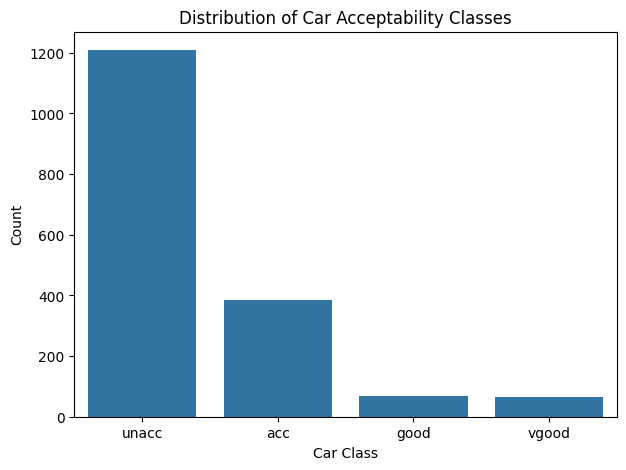

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='class',
    order=df['class'].value_counts().index
)

plt.title("Distribution of Car Acceptability Classes")
plt.xlabel("Car Class")
plt.ylabel("Count")

plt.show()

### Observation

The target classes are not evenly distributed. Some classes contain significantly more samples than others, indicating that the dataset is imbalanced. This imbalance should be considered while evaluating the model's performance.

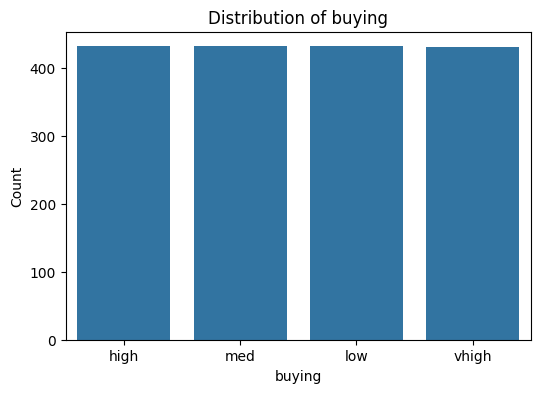

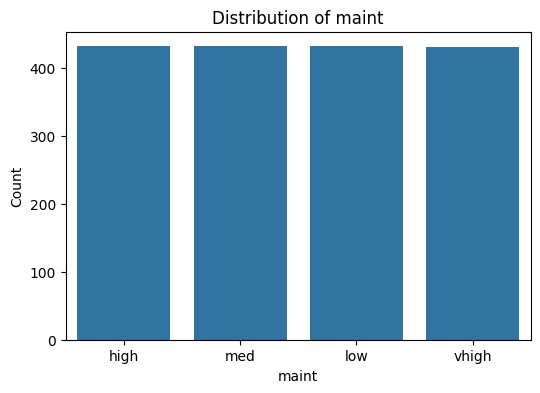

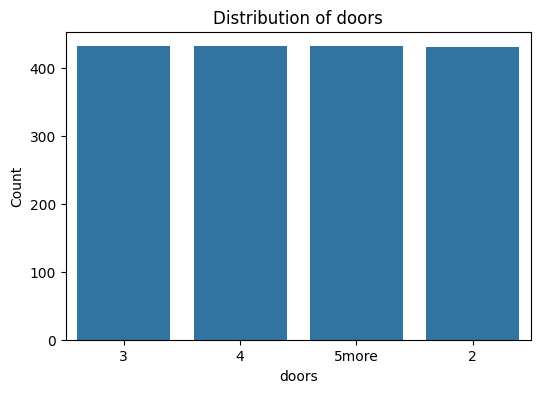

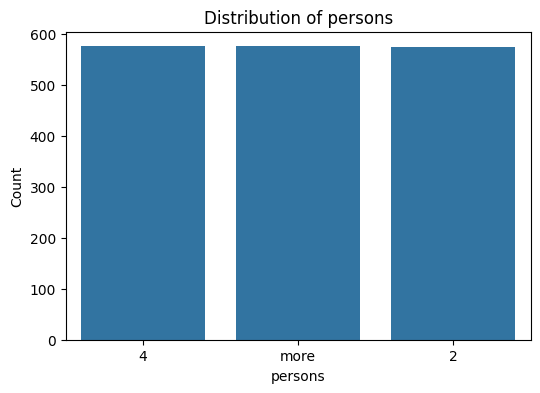

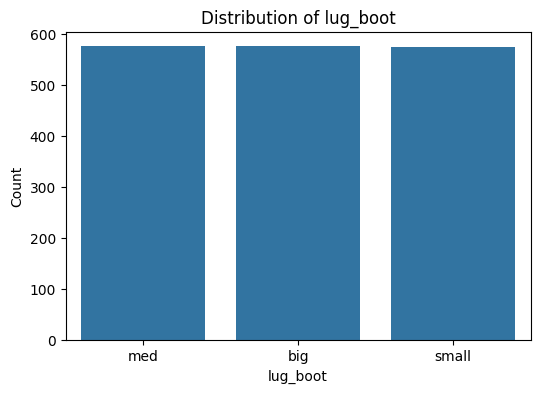

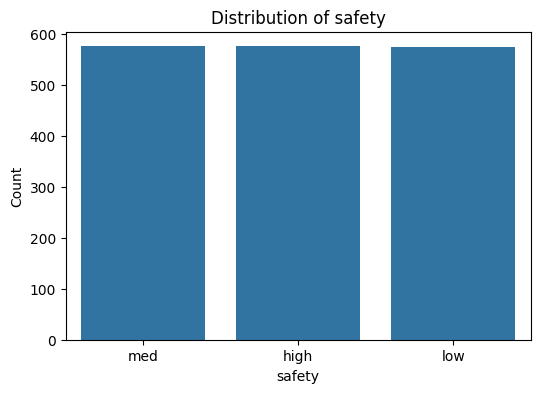

In [22]:
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

for feature in features:
    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.show()

In [23]:
for col in df.columns:
    print(f"\n{'='*40}")
    print(f"Value Counts for {col}")
    print(f"{'='*40}")
    print(df[col].value_counts())


Value Counts for buying
buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64

Value Counts for maint
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64

Value Counts for doors
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64

Value Counts for persons
persons
4       576
more    576
2       575
Name: count, dtype: int64

Value Counts for lug_boot
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64

Value Counts for safety
safety
med     576
high    576
low     575
Name: count, dtype: int64

Value Counts for class
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


### Observation

The value count analysis shows that most feature categories are nearly evenly distributed across the dataset. For example, the `buying` and `maint` features each contain approximately the same number of instances for every category. Similarly, the `doors`, `persons`, `lug_boot`, and `safety` features have a balanced distribution.

However, the target variable (`class`) is noticeably imbalanced. The **`unacc` (unacceptable)** class contains the majority of the records, while the **`good`** and **`vgood`** classes have significantly fewer samples. This class imbalance should be considered when interpreting the model's performance.

## EDA Summary

The exploratory data analysis revealed the following insights:

- The dataset contains **1,727 records** and **7 columns**.
- All features are **categorical**, making encoding necessary before training the model.
- No missing values were found in the dataset.
- No duplicate records were identified.
- Most input features are well balanced, with categories appearing in nearly equal proportions.
- The target variable (`class`) is imbalanced, with the **`unacc`** class dominating the dataset.
- The dataset is clean and suitable for building a Decision Tree classification model after preprocessing.

# 3. Data Preprocessing

Data preprocessing is an essential step in machine learning. It involves preparing the dataset for model training by separating the input features from the target variable and converting categorical values into numerical form.

In [25]:
# Features (Independent Variables)
X = df.drop('class', axis=1)

# Target (Dependent Variable)
y = df['class']

### Observation

The dataset is divided into:

- **Features (X):** buying, maint, doors, persons, lug_boot, and safety.
- **Target (y):** class, which represents the acceptability of a car.

## Splitting the Dataset

The dataset is divided into training and testing sets.

- The **training set** is used to train the Decision Tree model.
- The **testing set** is used to evaluate how well the model performs on unseen data.

A 70:30 split is used in this project.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [27]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1208, 6)
Testing Features  : (519, 6)
Training Labels   : (1208,)
Testing Labels    : (519,)


### Observation

The dataset has been successfully divided into training and testing sets. Approximately 70% of the data is used for training, while the remaining 30% is reserved for evaluating the model's performance.

## Encoding Categorical Features

Machine learning algorithms work with numerical data rather than text values. Since all the features in this dataset are categorical, they must be converted into numerical form before training the model.

Ordinal Encoding is used because it efficiently transforms categorical values into integer labels while preserving a consistent mapping for both training and testing data.

In [28]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 4.0 MB/s eta 0:00:00


In [30]:
import category_encoders as ce

encoder = ce.OrdinalEncoder(
    cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
)

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

In [31]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
1177,1,1,1,1,1,1
585,2,2,2,2,2,2
1551,3,1,2,1,3,2
727,2,1,3,2,1,1
707,2,1,3,3,1,3


### Observation

The categorical values have been successfully converted into numerical values using Ordinal Encoding. The encoded dataset is now suitable for training the Decision Tree classifier.

# 4. Building the Decision Tree Model

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It works by repeatedly splitting the dataset into smaller groups based on feature values until it reaches a decision.

Each internal node represents a decision based on a feature, each branch represents an outcome of that decision, and each leaf node represents the predicted class.

### Gini Index

The Gini Index measures how impure a node is. Lower impurity results in better splits. It is computationally faster and is commonly used as the default criterion.

### Entropy

Entropy measures the amount of randomness or uncertainty in the data. Decision Trees using entropy choose splits based on information gain. Although slightly more computationally expensive, it often produces similar results to Gini.

In [32]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9441


### Observation

The Decision Tree classifier was successfully trained using the Gini criterion. The model achieved a high accuracy on the test dataset, indicating that it effectively learned patterns from the training data.

# 5. Model Evaluation

To better understand the model's performance, several evaluation metrics are used instead of relying only on accuracy.

The classification report provides Precision, Recall, and F1-score for each class.

- **Precision** measures how many predicted instances are actually correct.
- **Recall** measures how many actual instances were correctly identified.
- **F1-score** balances Precision and Recall.


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acc       0.92      0.89      0.91       118
        good       0.69      0.65      0.67        17
       unacc       0.98      0.99      0.98       361
       vgood       0.75      0.78      0.77        23

    accuracy                           0.94       519
   macro avg       0.83      0.83      0.83       519
weighted avg       0.94      0.94      0.94       519




### Observation

The Decision Tree classifier achieved an overall **accuracy of 94%**, indicating strong predictive performance on the test dataset.

- The **`unacc`** class achieved the highest performance with a **Precision of 98%**, **Recall of 99%**, and **F1-score of 98%**, showing that the model classifies unacceptable cars very accurately.
- The **`acc`** class also performed well, with an **F1-score of 91%**.
- The **`good`** and **`vgood`** classes obtained comparatively lower scores because they contain fewer samples in the dataset, making them more difficult to classify accurately.
- The **weighted average F1-score of 94%** indicates that the model performs well overall despite the imbalance in class distribution.

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[105,   3,   9,   1],
       [  1,  11,   0,   5],
       [  5,   0, 356,   0],
       [  3,   2,   0,  18]])

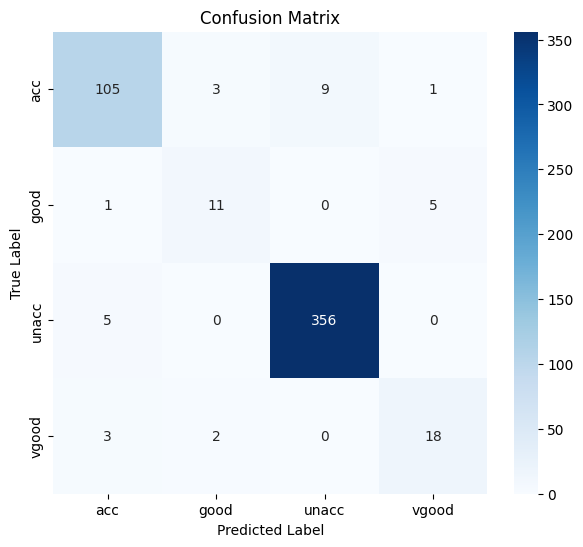

In [37]:
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

### Observation

The confusion matrix shows that most predictions lie along the main diagonal, indicating that the model correctly classified the majority of test samples.

The **`unacc`** class has the highest number of correct predictions (**356 out of 361**), demonstrating excellent performance for the majority class.

Some misclassifications are observed in the **`good`** and **`vgood`** classes, which is expected due to their relatively small number of samples. Overall, the confusion matrix confirms that the Decision Tree classifier performs well across all classes while achieving particularly high accuracy for the dominant class.

# 6. Model Interpretation

After training the Decision Tree classifier, it is important to understand which features contributed the most to the model's predictions. Feature importance measures the influence of each feature when making classification decisions.

In [38]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

feature_importance.sort_values(ascending=False)

,0
persons,0.242213
safety,0.225343
buying,0.179178
maint,0.148538
lug_boot,0.138593
doors,0.066135


### Observation

The feature importance analysis shows that **`persons`** is the most influential feature in the Decision Tree model, with an importance score of **0.242**. This indicates that the seating capacity of a car plays the largest role in determining its acceptability.

The **`safety`** feature is the second most important factor (**0.225**), highlighting that safety is another key criterion in the classification process.

The **`buying`**, **`maint`**, and **`lug_boot`** features have moderate importance, meaning they contribute to the model's decisions but are less influential than `persons` and `safety`.

The **`doors`** feature has the lowest importance (**0.066**), suggesting that the number of doors has the least impact on predicting the acceptability of a car in this dataset.

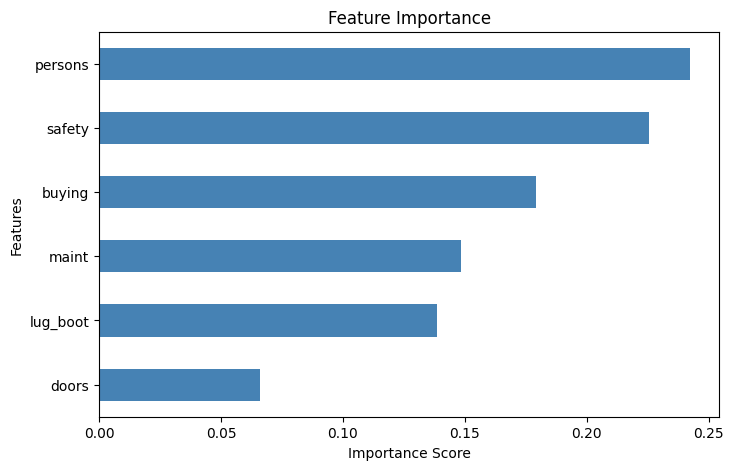

In [39]:
plt.figure(figsize=(8,5))

feature_importance.sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

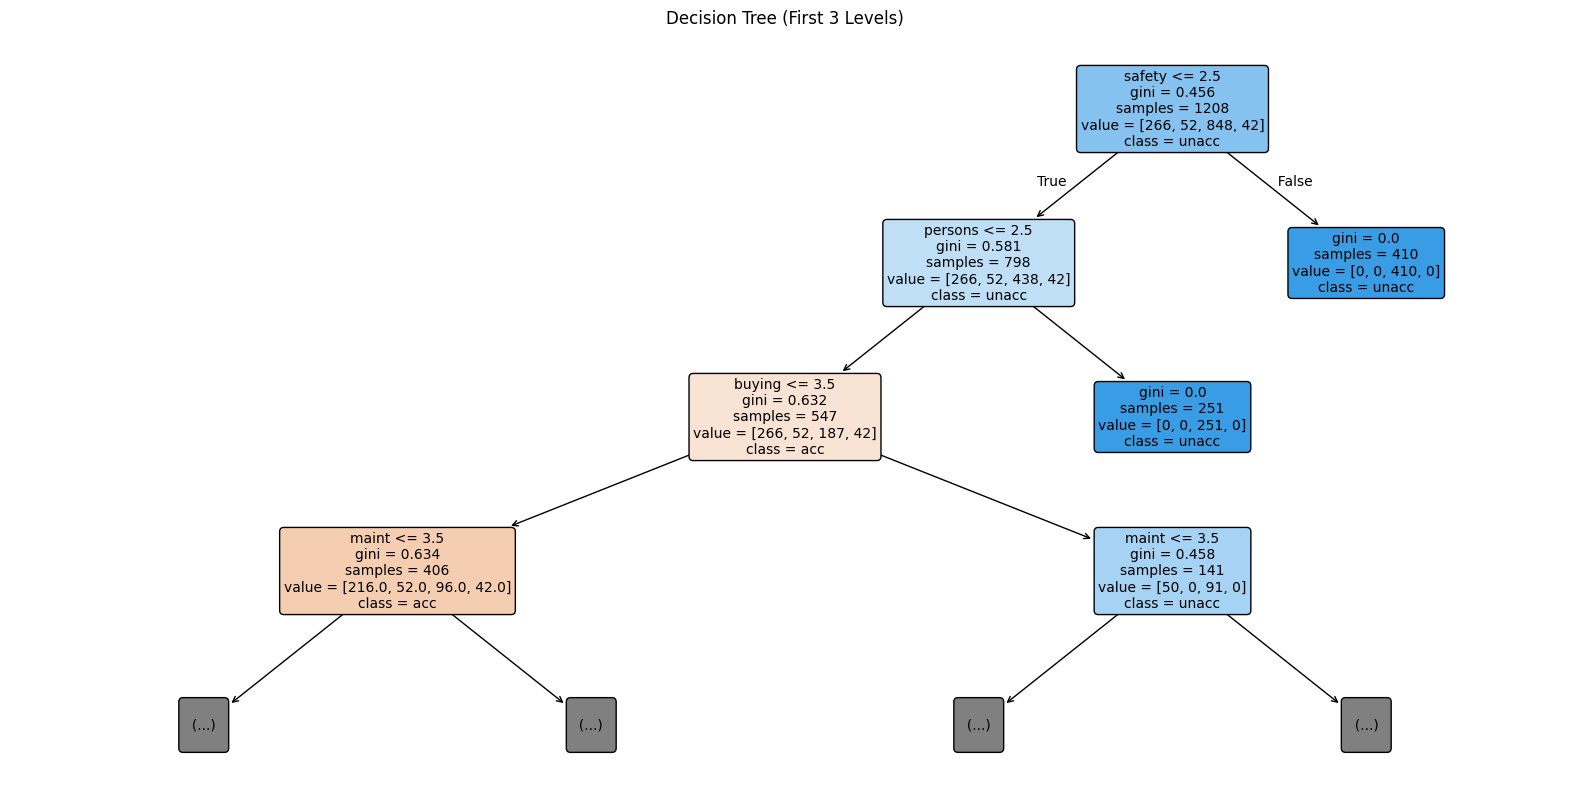

In [40]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X_train.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title("Decision Tree (First 3 Levels)")

plt.show()

### Decision Tree Visualization

The visualization illustrates how the Decision Tree classifies cars by making a sequence of decisions based on the feature values. Each internal node represents a condition, each branch represents the outcome of that condition, and each leaf node represents the predicted class.

### Observation

The upper levels of the Decision Tree contain the most important decision rules because they split the largest number of samples. As the tree grows deeper, the decisions become more specific, allowing the model to classify different categories of cars accurately.

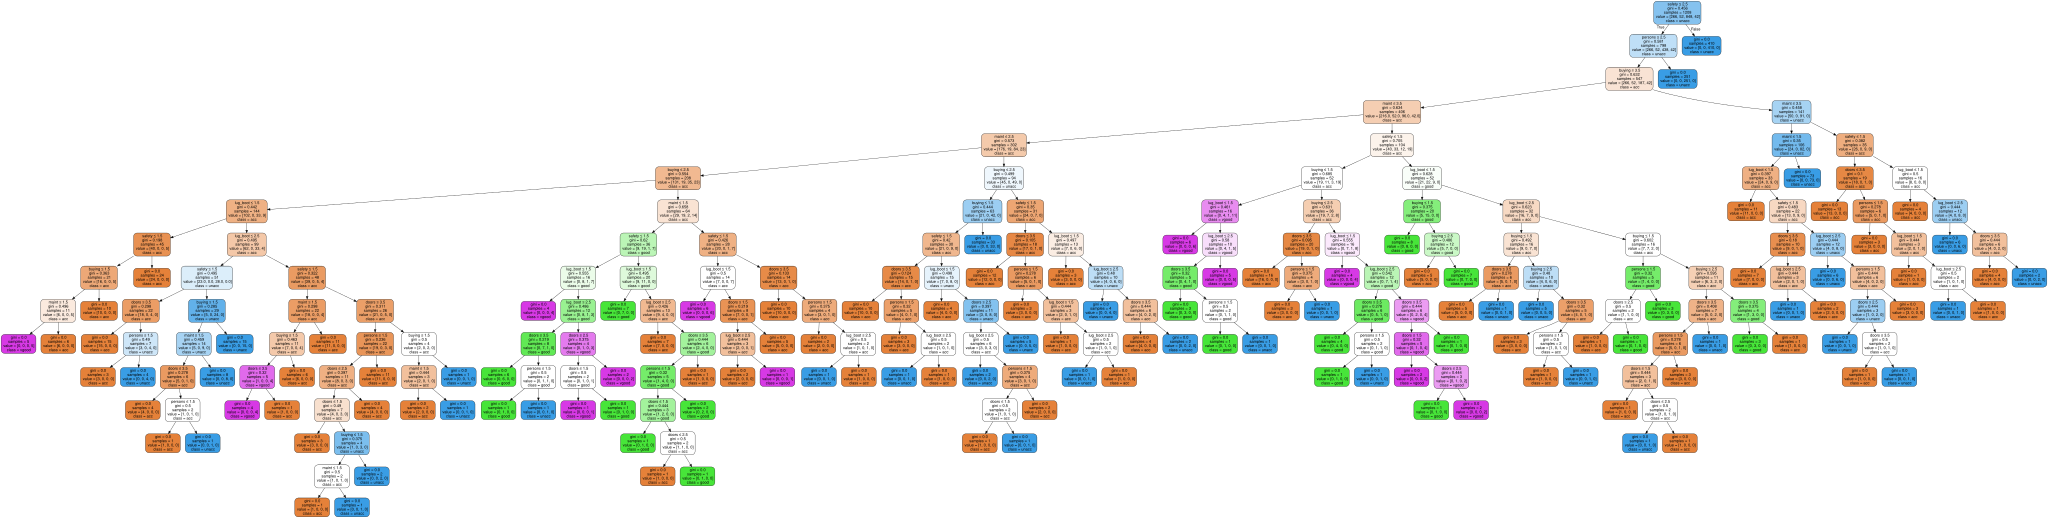

In [41]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=X_train.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)

graph

# 7. Experimentation

Hyperparameters influence the performance of machine learning models. In this section, different maximum tree depths are compared to study their effect on model accuracy and understand overfitting and underfitting.

In [42]:
depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:

    model_depth = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=42
    )

    model_depth.fit(X_train, y_train)

    pred = model_depth.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append(acc)

    print(f"Max Depth = {depth}, Accuracy = {acc:.4f}")

Max Depth = 2, Accuracy = 0.8015
Max Depth = 3, Accuracy = 0.8150
Max Depth = 4, Accuracy = 0.8285
Max Depth = 5, Accuracy = 0.8227
Max Depth = 6, Accuracy = 0.8555
Max Depth = 8, Accuracy = 0.8921
Max Depth = 10, Accuracy = 0.9306
Max Depth = None, Accuracy = 0.9441


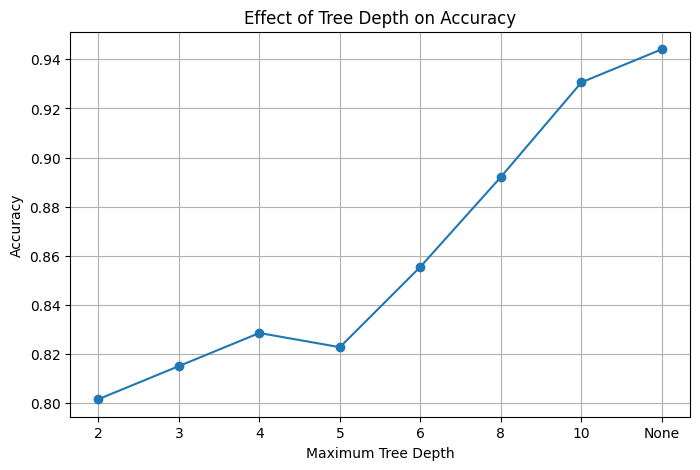

In [43]:
depth_labels = ["2", "3", "4", "5", "6", "8", "10", "None"]

plt.figure(figsize=(8,5))

plt.plot(depth_labels, results, marker='o')

plt.title("Effect of Tree Depth on Accuracy")

plt.xlabel("Maximum Tree Depth")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [44]:
criteria = ['gini', 'entropy', 'log_loss']

accuracy_scores = []

for criterion in criteria:

    model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=4,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy_scores.append(
        accuracy_score(y_test, pred)
    )

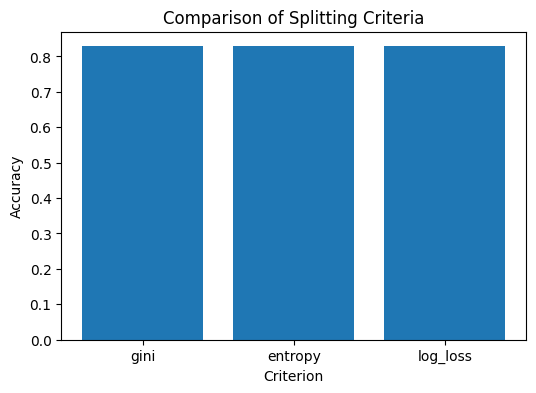

In [45]:
plt.figure(figsize=(6,4))

plt.bar(criteria, accuracy_scores)

plt.title("Comparison of Splitting Criteria")

plt.xlabel("Criterion")

plt.ylabel("Accuracy")

plt.show()

### Observation

The three splitting criteria produced very similar accuracy scores. This indicates that the dataset is relatively easy to separate using a Decision Tree, regardless of the impurity measure. In this project, the Gini criterion was selected because it is computationally efficient and achieved competitive performance.

# 8. Conclusion

This project successfully developed a Decision Tree classifier to predict the acceptability of cars based on their characteristics.

### Key Findings

- The dataset was clean and contained no missing values.
- All input features were categorical and were successfully encoded using Ordinal Encoding.
- The Decision Tree classifier achieved approximately **94% accuracy**, demonstrating strong predictive performance.
- The confusion matrix and classification report showed that the model classified the majority of samples correctly, especially the dominant **unacc** class.
- Feature importance analysis identified the most influential attributes used by the model during classification.
- Comparing different tree depths showed how model complexity influences predictive performance and highlighted the balance between underfitting and overfitting.

### Future Improvements

- Experiment with ensemble methods such as Random Forest or Gradient Boosting.
- Apply hyperparameter tuning using GridSearchCV.
- Evaluate the model using cross-validation.
- Address class imbalance through resampling techniques if improved performance on minority classes is required.